# Fase 3 — pipeline de geração de questões de múltipla escolha

Geração iterativa de MCQ do domínio de FPSO, ancorada no corpus **Petrolês**,
com julgamento automático, controle de vícios de construção e critério de
parada por entropia.

## O que herda das fases anteriores

| da fase 2 | vira, na fase 3 |
|---|---|
| 30 pares de questões avaliados por especialistas | **banco seed** de few-shot (as vencedoras) |
| critérios do formulário (clareza, alternativas, correção técnica, relevância) | **rubrica do judge** — a nota deixa de ser arbitrária |
| prompt `PORTUGUESE_V15` | base do prompt do gerador |

## O pipeline (passos 0 a 9)

```
0. insumos     corpus Petrolês · 17 tópicos / 40 subtópicos com instrução do
               especialista · banco seed de questões de alta qualidade
1. recuperação query do subtópico -> N trechos do corpus
2. consolidação LLM resume os N trechos em um documento de geração enxuto
3. geração     lote de questões a partir do documento + few-shot sorteado
4. judgment    LLM-as-judge em lote, baixo esforço: descarta incorretas,
               atribui nota [0,1] e dificuldade
5. vícios      scorer determinístico: similaridade, comprimento, distratores
6. tolerância  passou do limite -> refinamento -> re-scorer -> passa ou descarta
7. storage     embedding(questão+correta), origem, nota, dificuldade, vícios
8. realimenta  questões de alto score entram no pool de few-shot
9. parada      entropia de Shannon do pool do subtópico; 5 rodadas sem ganho
               -> próximo documento / subtópico
```

## Modelos

| papel | deployment |
|---|---|
| gerador, judge, refinador | `gpt-5-petrobras` |
| extrator de facetas, consolidador | `gpt-4o-mini-petrobras` |
| embeddings | `sentence-transformers` multilíngue, local |

## Onde está o código

O notebook orquestra; o motor está em três módulos ao lado dele:

- `utils_fase3.py` — varredura do corpus, embeddings, recuperação, scorer de
  vícios, entropia, repositório e estado;
- `prompts_fase3.py` — todos os prompts (extrator, consolidador, gerador,
  judge, refinador);
- `seed_fase3.py` — construção do banco seed a partir do formulário da fase 2.

## 1. Setup

In [1]:
# pip install openai httpx sentence-transformers scikit-learn numpy pandas
import sys, json, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

AQUI = Path.cwd()                      # pipeline/fase_3
RAIZ = (AQUI / ".." / "..").resolve()  # raiz do repositório
sys.path.insert(0, str(AQUI))
sys.path.insert(0, str(RAIZ))

import utils_fase3 as U
import prompts_fase3 as P
import seed_fase3 as S
from topicos import TOPICOS
from azure_openai_backend import AzureOpenAIBackend

pd.set_option("display.max_colwidth", 90)
print(f"raiz: {RAIZ}")
print(f"tópicos: {len(TOPICOS)} · subtópicos: {sum(len(v) for v in TOPICOS.values())}")

raiz: /home/gbs2/MCQ_CONTEXT_GEN
tópicos: 10 · subtópicos: 40


In [2]:
cfg = U.Config(
    raiz=RAIZ,
    corpus_dir=RAIZ / "dataset" / "corpus-SemProcessamento-publico-PetrolesCompleto",
    
    # corpus_ignorar=["NILC.txt"],   # ver §4: exclui um arquivo sem mexer na pasta
    out_dir=AQUI / "saida_fase3",
    # --- modelos ---------------------------------------------------------
    modelo_forte="gpt-5-4-petrobras",
    modelo_leve="gpt-5-mini-petrobras",
    # --- piloto ----------------------------------------------------------
    
    # O limiar de entropia é calibrado no fim deste notebook, com os ganhos
    # observados. Começa baixo de propósito: no piloto queremos ver as rodadas
    # improdutivas acontecerem, não evitá-las.
    limiar_ganho_entropia=0.001,
    rodadas_estagnadas_max=5,
    min_questoes_para_entropia=12,
    n_questoes_por_lote=6,
    n_exemplos_fewshot=3,
)
print(cfg.resumo())

{
  "raiz": "/home/gbs2/MCQ_CONTEXT_GEN",
  "corpus_dir": "/home/gbs2/MCQ_CONTEXT_GEN/dataset/corpus-SemProcessamento-publico-PetrolesCompleto",
  "corpus_txt": [],
  "corpus_zip": null,
  "corpus_ignorar": [],
  "out_dir": "/home/gbs2/MCQ_CONTEXT_GEN/pipeline/fase_3/saida_fase3",
  "modelo_forte": "gpt-5-4-petrobras",
  "modelo_leve": "gpt-5-mini-petrobras",
  "modelo_embedding": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
  "judge_reasoning_effort": "low",
  "gerador_reasoning_effort": "medium",
  "n_facetas_max": 6,
  "alvo_palavras_trecho": 250,
  "sobreposicao_trecho": 0.5,
  "max_linhas_trecho": 120,
  "min_palavras": 80,
  "max_palavras": 450,
  "max_frac_number": 0.15,
  "top_k_lexical": 300,
  "peso_termo_forte": 3.0,
  "peso_termo_apoio": 1.0,
  "cap_termos": 6,
  "n_trechos_por_documento": 6,
  "n_documentos_por_faceta": 4,
  "peso_lexical": 0.4,
  "peso_semantico": 0.6,
  "mmr_lambda": 0.7,
  "mmr_dup_threshold": 0.92,
  "max_palavras_documento": 900,
  "

In [3]:
# Um deployment por papel. O backend cacheia em disco por hash do pedido, então
# reexecutar o notebook não repaga as chamadas idênticas.
llm_leve = AzureOpenAIBackend(deployment=cfg.modelo_leve, max_tokens=3000)
llm_gerador = AzureOpenAIBackend(deployment=cfg.modelo_forte, max_tokens=12000,
                                 reasoning_effort=cfg.gerador_reasoning_effort)
llm_judge = AzureOpenAIBackend(deployment=cfg.modelo_forte, max_tokens=8000,
                               reasoning_effort=cfg.judge_reasoning_effort)
# O refinador é o mesmo gpt-5 do gerador — reescrever questão é tarefa de autor.
llm_refinador = llm_gerador

llm_leve.doctor()

Configuração (segredos mascarados):
  azure_endpoint: https://api***.petrobras.com.br/ia/openai/v1/openai-azure/openai
  azure_api_key: <definida:72ce953d>
  azure_api_version: 2024-10-21
  default_deployment: None
  ca_bundle: /home/gbs2/MCQ_CONTEXT_GEN/petrobras-ca-root.pem
  use_base_url: True
  dotenv_path: /home/gbs2/MCQ_CONTEXT_GEN/.env
  dotenv_found: True
  config_ini: None
  placeholders: []
  deployment: gpt-5-mini-petrobras (reasoning=True)
Fazendo uma chamada de teste...
  resposta: 'ok'
OK.


## 2. Passo 0 — insumos fixos

### 2.1 Banco seed: as vencedoras do formulário da fase 2

Em cada um dos 30 pares, os especialistas escolheram a melhor questão. A
`nota_humana` é a margem de vitória normalizada pelo número de avaliadores —
com 2 avaliadores, `1.0` é unânime e `0.5` é decidida por um voto. Empates
ficam de fora.

In [4]:
DIR_FASE2 = RAIZ / "pipeline" / "fase_2" / "questionarios" / "respostas_questionario"

banco_seed = S.construir_banco_seed(DIR_FASE2, min_nota_humana=0.5)
S.salvar_banco_seed(banco_seed, cfg.out_dir / "banco_seed.jsonl")

q = banco_seed[0]
print(f"\n--- exemplo ({q['id']}, nota humana {q['nota']}, {q['condicao']}) ---")
print(q["stem"])
for i, a in enumerate(q["alternatives"]):
    print(f"  {'>' if i == q['correct_answer_index'] else ' '} {chr(65+i)}) {a[:110]}")

banco seed: 22 questões de 30 pares (2 avaliadores)
  por condição: {'instruction-only': 12, 'context-grounded': 10}
  por nota humana: {1.0: 6, 0.5: 16}
  descartados (empate ou sem voto decisivo): 8

--- exemplo (seed-03, nota humana 0.5, instruction-only) ---
Em um cenário de descomissionamento planejado de um FPSO, a gestão de riscos deve priorizar a análise de impacto ambiental e a viabilidade econômica da desmontagem. Qual fator técnico é crítico para determinar se a desmontagem será realizada 'in situ' (no mar) ou em terra, influenciando diretamente o custo e o risco logístico?
    A) A capacidade de produção média dos últimos cinco anos, pois unidades com baixa produção histórica têm priorida
  > B) A presença de contaminantes persistentes (como amianto ou PCBs) e a complexidade estrutural que dificultam o t
    C) A idade cronológica da unidade, pois equipamentos acima de 20 anos são proibidos por lei de serem desmontados 
    D) O tipo de sistema de ancoragem utilizado, pois 

### 2.2 Tópicos, subtópicos e a instrução do especialista

O problema prático: as instruções de `topicos.py` vão de 350 a **6.400
caracteres** e enumeram muitos assuntos independentes numa frase só.

Usar esse parágrafo inteiro como query de busca não funciona — o embedding do
parágrafo é a média de dez assuntos, e recupera o genérico de todos em vez do
específico de qualquer um. E usá-lo inteiro no prompt de geração dá sempre o
mesmo alvo: as rodadas se repetem, que é exatamente o que o critério de parada
deveria estar medindo.

In [5]:
tamanhos = [(t, s, len(instr)) for t, subs in TOPICOS.items()
            for s, instr in subs.items()]
df_top = pd.DataFrame(tamanhos, columns=["topico", "subtopico", "chars_instrucao"])
print(f"{len(df_top)} subtópicos · instrução de {df_top.chars_instrucao.min()} a "
      f"{df_top.chars_instrucao.max()} caracteres (mediana {df_top.chars_instrucao.median():.0f})")
df_top.sort_values("chars_instrucao", ascending=False).head(8)

40 subtópicos · instrução de 355 a 6357 caracteres (mediana 2548)


,topico,subtopico,chars_instrucao
39,Descomissionamento e Gestão do Ciclo de Vida da Unidade,Geral,6357
31,"Manutenção, Inspeção e Integridade de Ativos","Apoio Técnico e Manutenção em um FPSO (Laboratório, Oficinas, Pipe Shop)",4967
37,"Logística, Suprimentos e Movimentação de Cargas",Logística e Suprimento Offshore,4058
38,"Logística, Suprimentos e Movimentação de Cargas",Movimentação de Cargas,3942
35,"Segurança Ocupacional, Saúde e Meio Ambiente",Gestão de Pessoas e Treinamento,3422
29,"Manutenção, Inspeção e Integridade de Ativos",Manutenção e Plano de Manutenção,3377
30,"Manutenção, Inspeção e Integridade de Ativos",Inspeção e Integridade,3319
28,"Manutenção, Inspeção e Integridade de Ativos",Cibersegurança e Integridade de Sistemas Digitais,3190


### 2.3 Escopo do piloto

Rodar os 40 subtópicos antes de calibrar o limiar de entropia é caro e cego.
O piloto roda três subtópicos de perfis diferentes — um bem coberto pelo
corpus, um normativo, um de gestão — até a estagnação, e é dele que sai o
limiar.

A varredura do corpus (§4), essa sim, roda uma vez só e vale para tudo: basta
incluir todos os subtópicos na lista de facetas quando quiser expandir.

In [6]:
SUBTOPICOS_PILOTO = [
    ("Produção e Processo (Medição Fiscal e Sistema de Alívio)",
     "Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia "
     "em operações de offloading"),
    ("Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos", "SGSO"),
    ("Manutenção, Inspeção e Integridade de Ativos", "Manutenção e Plano de Manutenção"),
]

for t, s in SUBTOPICOS_PILOTO:
    assert s in TOPICOS[t], f"subtópico ausente em topicos.py: {s}"
    print(f"{t}\n  -> {s} ({len(TOPICOS[t][s])} chars)")

# Para rodar tudo:
# SUBTOPICOS_PILOTO = [(t, s) for t, subs in TOPICOS.items() for s in subs]

Produção e Processo (Medição Fiscal e Sistema de Alívio)
  -> Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações de offloading (503 chars)
Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos
  -> SGSO (2777 chars)
Manutenção, Inspeção e Integridade de Ativos
  -> Manutenção e Plano de Manutenção (3377 chars)


## 3. Facetas — a técnica para as instruções longas

O extrator (`gpt-4o-mini`) quebra cada instrução em **facetas**: recortes
técnicos independentes daquilo que o especialista pediu. Cada faceta é usada
três vezes, e é isso que torna a técnica barata:

| a faceta fornece | usado em |
|---|---|
| `termos_fortes` / `termos_apoio` | busca lexical no corpus (§4) |
| `query` | rerank semântico (§5) |
| `foco` | a instrução do especialista no prompt de geração (§7) |

O ganho não é só de recuperação. Como cada rodada mira uma faceta diferente, a
diversidade entre rodadas vem do desenho, e não de pedir "faça diferente" ao
modelo. Nada é inventado fora da instrução — o extrator só a decompõe.

O resultado fica em cache (`saida_fase3/indices/facetas.jsonl`); apague o
arquivo para reextrair.

In [7]:
facetas = U.extrair_facetas(llm_leve, TOPICOS, cfg,
                            subtopicos_alvo=SUBTOPICOS_PILOTO)
por_sub = U.agrupar_por_subtopico(facetas)
print(f"\n{len(facetas)} facetas em {len(por_sub)} subtópicos")


17 facetas em 3 subtópicos


In [8]:
f = facetas[0]
print(f"faceta: {f.titulo}\n")
print(f"foco (vai para o prompt de geração):\n  {f.foco}\n")
print(f"query (rerank semântico):\n  {f.query}\n")
print(f"termos fortes: {f.termos_fortes}")
print(f"termos de apoio: {f.termos_apoio}")

faceta: projeto e instalacao de sistema de medicao fiscal

foco (vai para o prompt de geração):
  As questões devem abordar requisitos de projeto e instalação dos sistemas de medição fiscal usados em offloading de FPSO, incluindo arranjo físico, seleção de tecnologia de medicao e requisitos de integridade e compatibilizacao com linhas de transferencias.

query (rerank semântico):
  requisitos projeto instalacao sistema medicao fiscal offloading fpso arranjo fisico selecion tecnologia medicao integridade compatibilizacao linhas transferencia

termos fortes: ['arranjo fisico medicao', 'escolha medidor fiscal', 'linha de offloading']
termos de apoio: ['fps0', 'offloading', 'medidor proveta', 'ultrassonico', 'caudalimetro', 'tubulacao']


## 4. Passo 1a — varredura do corpus (estágio lexical)

O corpus vive em `dataset/corpus-SemProcessamento-publico-PetrolesHibrido/` e são
**três** arquivos. Se a pasta não existir, `python setup_dataset.py` na raiz do
repositório baixa e extrai tudo (`--variante completo` traz só os dois de óleo e
gás, sem o NILC). `cfg.corpus_dir` aponta para a pasta e a varredura lê todos os
`.txt` dela, em ordem alfabética, tratando-os como um corpus só — a célula
abaixo lista exatamente o que vai ser lido, que é o momento barato de perceber
um arquivo a mais ou a menos.

Os três não têm a mesma forma, e isso importa:

| arquivo | tamanho | linhas | palavras/linha | `<NUMBER>` |
|---|---|---|---|---|
| `corpusPublico(sem IBICT)` | 0,54 GB | ~3,4 M | ~25 | sim |
| `corpusPublicoIBICT` | 0,43 GB | ~2,6 M | ~26 | sim |
| `NILC.txt` | 3,71 GB | ~110,5 M | ~7 | não |

**Por isso a janela é medida em palavras, não em linhas.** Uma janela de 12
linhas daria ~300 palavras nos dois primeiros e ~85 no NILC — trechos
incomparáveis, e no NILC fragmentos curtos demais para gerar questão. A
varredura acumula linhas até `alvo_palavras_trecho` (250) e desliza mantendo
`sobreposicao_trecho` (50%), então todo trecho sai do mesmo tamanho venha de
onde vier. A janela nunca cruza a fronteira entre arquivos.

### Sobre o NILC

O NILC é **95% das linhas do corpus** e é texto geral do português (notícias,
literatura, legendas — a primeira página são falas de um programa infantil),
não óleo e gás. O *gate* lexical exige um termo forte da faceta para o trecho
entrar, o que o filtra bem; mas ele responde por ~7 dos ~8 minutos de varredura.

Não estou excluindo por conta própria: rode com os três e olhe a tabela
`candidatos por arquivo` que a varredura imprime no fim. Se o NILC aparecer com
uma fatia irrisória de candidatos — o que é o esperado —, `cfg.corpus_ignorar =
["NILC.txt"]` corta a reindexação para menos de um minuto nas próximas vezes.

### Os dois estágios

1. **lexical, streaming** (aqui) — uma passada pontuando **todas as facetas ao
   mesmo tempo**, guardando os top-K trechos de cada uma. O léxico vem dos
   termos que o extrator produziu, não de listas escritas à mão. Um *gate* exige
   ao menos um termo forte (ou dois de apoio), o que corta falso positivo de
   termo genérico.
2. **semântico** (§5) — rerank e MMR só sobre esses candidatos, porque embeddar
   milhões de trechos é inviável.

Custa ~8 min com os três arquivos e roda **uma vez** por conjunto de facetas: o
resultado é verificado por assinatura (que inclui a lista de arquivos) e
reaproveitado depois. Mudou a lista de arquivos ou o conjunto de facetas, a
assinatura muda e a varredura refaz.

> `limite_linhas=500_000` faz um teste de fumaça rápido. Confira os candidatos,
> apague `saida_fase3/indices/candidatos*` e rode de novo sem o limite.

In [9]:
U.descrever_corpus(cfg)

corpus: 2 arquivo(s), 0.97 GB, ~6M linhas
  corpusPublico(sem IBICT)-SemProcessamento.txt      0.54 GB · ~   3.4M linhas ·  25.2 palavras/linha ·   57% das linhas
  corpusPublicoIBICT-SemProcessamento.txt            0.43 GB · ~   2.6M linhas ·  26.1 palavras/linha ·   43% das linhas


[{'arquivo': 'corpusPublico(sem IBICT)-SemProcessamento.txt',
  'bytes': 541421503,
  'linhas_est': 3414095,
  'palavras_por_linha': 25.2},
 {'arquivo': 'corpusPublicoIBICT-SemProcessamento.txt',
  'bytes': 428577691,
  'linhas_est': 2625874,
  'palavras_por_linha': 26.1}]

In [10]:
%%time
U.varrer_corpus(facetas, cfg)          # limite_linhas=500_000 para um teste rápido
candidatos = U.carregar_candidatos(cfg)

resumo = pd.DataFrame([
    {"faceta": f.titulo[:44], "subtopico": f.subtopico[:34],
     "candidatos": len(candidatos.get(f.id, [])),
     "lex_max": max([c["lex_score"] for c in candidatos.get(f.id, [])], default=0)}
    for f in facetas
])
resumo

índice já existe e confere (/home/gbs2/MCQ_CONTEXT_GEN/pipeline/fase_3/saida_fase3/indices/candidatos.jsonl) — reaproveitando
CPU times: user 8.65 ms, sys: 49.6 ms, total: 58.3 ms
Wall time: 142 ms


,faceta,subtopico,candidatos,lex_max
0,projeto e instalacao de sistema de medicao f,"Medição Fiscal de óleo, medição fi",47,4.0
1,"operacao, calibracao e verificacao","Medição Fiscal de óleo, medição fi",300,4.0
2,controle metrologico e rastreabilidade,"Medição Fiscal de óleo, medição fi",104,4.0
3,"tratamento e validacao de dados, volumes e p","Medição Fiscal de óleo, medição fi",300,4.0
4,"incerteza, registros, auditoria e conformida","Medição Fiscal de óleo, medição fi",0,0.0
5,governanca e cultura de seguranca,SGSO,17,4.0
6,"qualificacao, treinamento e contratadas",SGSO,300,3.0
7,identificacao e analise de riscos e acao cor,SGSO,113,5.0
8,elementos criticos de seguranca e integridad,SGSO,42,4.0
9,"procedimentos operacionais, simops e mudanca",SGSO,89,4.0


In [11]:
# Contribuição de cada arquivo do corpus — é esta tabela que decide se vale
# manter o NILC na varredura ou pô-lo em cfg.corpus_ignorar.
manifesto = json.loads(
    (cfg.out_dir / "indices" / "candidatos_manifesto.json").read_text(encoding="utf-8"))
print(f"varredura: {manifesto['n_linhas']:,} linhas em "
      f"{manifesto['segundos'] / 60:.1f} min\n")
pd.DataFrame([
    {"arquivo": a,
     "linhas_lidas": manifesto["linhas_por_arquivo"].get(a, 0),
     "trechos_avaliados": manifesto["trechos_avaliados_por_arquivo"].get(a, 0),
     "candidatos_finais": manifesto["candidatos_por_arquivo"].get(a, 0)}
    for a in manifesto["arquivos"]
]).assign(share_candidatos=lambda d: (d.candidatos_finais / max(d.candidatos_finais.sum(), 1)).map("{:.1%}".format))

varredura: 7,152,491 linhas em 1.6 min



,arquivo,linhas_lidas,trechos_avaliados,candidatos_finais,share_candidatos
0,corpusPublico(sem IBICT)-SemProcessamento.txt,4479565,1771,1319,67.7%
1,corpusPublicoIBICT-SemProcessamento.txt,2672926,590,629,32.3%


In [12]:
# Inspeção manual — a etapa mais barata de detectar recuperação ruim.
f = facetas[0]
for c in candidatos[f.id][:2]:
    print(f"[{c['chunk_id']}] lex={c['lex_score']:.0f} termos={c['termos_fortes']}")
    print(c["texto"][:600], "...\n")

[corpusPublico(sem IBICT)-SemProcessamento.txt:1235399-1235411] lex=4 termos=['linha de offloading']
<NUMBER> INGRESOS POR VENTAS <NUMBER> <NUMBER> UTILIDAD SIN IMPUESTOS TRANSFERENCIAS Y PARTICIPACIONES <NUMBER> <NUMBER> UTILIDAD DE LA GESTIÓN <NUMBER> <NUMBER> ACTIVO TOTAL <NUMBER> <NUMBER> PATRIMONIO <NUMBER> <NUMBER> TOTAL TRABAJADORES <NUMBER> INFLACIÓN <NUMBER> <NUMBER> VENTAS <NUMBER> Bpd <NUMBER> ANCAP RECURSOS HUMANOS UNIVERSIDADE PETROBRAS ESCOLA DE CIÊNCIAS E TECNOLOGIA DE EXPLORAÇÃO E PRODUÇÃO PÓS-GRADUAÇÃO EM ENGENHARIA DE PETRÓLEO E GÁS NATURAL CARLOS YUJI ENDO ESTUDO DE DESLOCAMENTO DE ÓLEO NA LINHA DE OFFLOADING UTILIZANDO O MÉTODO MPS Macaé <NUMBER> RECURSOS HUMANOS UNIVERSID ...

[corpusPublico(sem IBICT)-SemProcessamento.txt:1235407-1235420] lex=4 termos=['linha de offloading']
Orientador: Ricardo Migueis Picado Co-orientador: Tiago Zampieri DAndrea Macaé <NUMBER> RESUMO Uma das causas do problema da elevada quantidade de água na carga dos navios aliviadores está no 

## 5. Passo 1b — rerank semântico, MMR e a fila de documentos

O embedder é o `sentence-transformers` multilíngue rodando local — o mesmo
vetor serve ao rerank, ao MMR, ao scorer de vícios (§8) e à entropia (§10),
o que mantém as quatro medidas na mesma geometria.

O score final combina lexical e semântico em z-scores; o **MMR** seleciona
trechos relevantes *e* diversos entre si (senão o documento consolidado vira
seis paráfrases da mesma passagem). Os selecionados são fatiados em blocos de
`n_trechos_por_documento` — cada bloco é um **documento** no sentido do passo 1,
e é a unidade que o critério de parada percorre quando o subtópico satura.

A fila intercala as facetas (`f0d0, f1d0, f2d0, f0d1, ...`): o subtópico cobre
a largura da instrução antes de aprofundar em qualquer recorte.

In [13]:
emb = U.Embedder(cfg)

planos = {}
for subtopico, fs in por_sub.items():
    print(f"\n{subtopico}")
    planos[subtopico] = U.plano_de_documentos(fs, candidatos, emb, cfg)
    print(f"    fila: {len(planos[subtopico])} documentos")

/home/gbs2/MCQ_CONTEXT_GEN/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 532.46it/s]
/home/gbs2/MCQ_CONTEXT_GEN/pipeline/fase_3/utils_fase3.py:689: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dim = self.model.get_sentence_embedding_dimension()


embedder: paraphrase-multilingual-MiniLM-L12-v2 (dim=384) · cache com 3126 vetores

Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações de offloading
    projeto e instalacao de sistema de medicao fiscal       47 cand -> 4 doc(s)
    operacao, calibracao e verificacao                     300 cand -> 4 doc(s)
    controle metrologico e rastreabilidade                 104 cand -> 4 doc(s)
    tratamento e validacao de dados, volumes e proprieda   300 cand -> 4 doc(s)
    incerteza, registros, auditoria e conformidade anp       0 cand -> 0 doc(s)
    fila: 16 documentos

SGSO
    governanca e cultura de seguranca                       17 cand -> 3 doc(s)
    qualificacao, treinamento e contratadas                300 cand -> 4 doc(s)
    identificacao e analise de riscos e acao corretiva     113 cand -> 4 doc(s)
    elementos criticos de seguranca e integridade mecani    42 cand -> 4 doc(s)
    procedimentos operacionais, simops e mudancas           89 ca

## 6. Passo 2 — consolidação

O `gpt-4o-mini` transforma os N trechos brutos num documento técnico enxuto.
A regra dura do prompt é **não acrescentar conhecimento**: o consolidador
limpa, funde e descarta ruído, mas o que ele não recebeu não pode aparecer. Se
os trechos forem pobres, ele deve dizê-lo com o prefixo `AVISO:` — o que
transforma recuperação ruim em algo visível, em vez de virar questão inventada
lá na frente.

Documentos consolidados ficam em `saida_fase3/documentos/`.

In [14]:
subtopico_demo = SUBTOPICOS_PILOTO[0][1]
plano_demo = planos[subtopico_demo]
fac_por_id = {f.id: f for f in facetas}

doc = plano_demo[0]
faceta = fac_por_id[doc["faceta_id"]]
documento = U.consolidar_documento(llm_leve, doc, faceta, cfg)

print(f"documento {doc['doc_id']} · faceta '{faceta.titulo}' · "
      f"{len(doc['trechos'])} trechos -> {len(documento.split())} palavras\n")
print(documento[:1500])

documento 80d9d9002a-f0-d0 · faceta 'projeto e instalacao de sistema de medicao fiscal' · 6 trechos -> 809 palavras

Requisitos de arranjo físico

O arranjo físico dos sistemas de medição fiscal para offloading deve considerar a interface direta com a linha de transferência do FPSO e com o mangote do navio aliviador. Conexões por flanges e parafusos, típicas em operações convencionais, apresentam riscos relevantes: impossibilidade de desconexão em emergência por dificuldades de posicionamento do navio ou condições ambientais adversas; e dobramento excessivo do mangote, que acelera desgaste das camadas externas e exige trocas frequentes. Sistemas de acoplamento do tipo BLS (BLS Coupler) mitigam esses problemas por meio de uma articulação esférica que providencia movimentação livre de momentos e reduz esforços no mangote. O manuseio desses mangotes é efetuado por linhas que centralizam o puxamento na direção do eixo, com interface no padrão Mar do Norte (North Sea Valve - NSV).

A faixa 

## 7. Passo 3 — geração

O prompt do gerador é o `PORTUGUESE_V15` da fase 2 com três acréscimos: o
`foco` da faceta (a instrução do especialista para aquele recorte), o documento
consolidado como **única fonte factual**, e o few-shot sorteado do banco de
alto score.

O few-shot é sorteado de **qualquer tópico**, de propósito: ele calibra forma —
profundidade, construção de distrator, tom — e não conteúdo. Exemplos do mesmo
subtópico convidariam o modelo a copiar o assunto.

O escopo do gerador é estreito de propósito: **enunciado, alternativas e
gabarito, e nada mais**. Dificuldade é do judge, que tem a rubrica na mão;
justificativa da correta não é produzida por ninguém; e a posição do gabarito é
sorteada no pós-processamento (§11). Cada um desses pedidos, quando está no
prompt, consome atenção do modelo em contabilidade que código faz melhor — e a
variação de posição entre A/B/C/D é o exemplo mais claro: é uma propriedade do
lote inteiro, que o modelo estima mal.

Um detalhe que evita um bug caro: o backend cacheia por hash do pedido, então
duas rodadas com o mesmo documento e o mesmo few-shot devolveriam questões
idênticas do cache. O prompt carrega um marcador de rodada — rodadas diferentes
divergem, a *mesma* rodada continua cacheável e o notebook pode ser reexecutado
de graça.

In [15]:
repo = U.Repositorio(cfg, emb)
pool = U.PoolFewShot(banco_seed, repo, cfg)
print("pool de few-shot:", pool.composicao())

exemplos = pool.amostrar(excluir_subtopico=faceta.subtopico)
print(f"exemplos sorteados: {[e['id'] for e in exemplos]}")

geradas = U.gerar_lote(llm_gerador, doc, faceta, documento, exemplos,
                       rodada=1, cfg=cfg)
print(f"\n{len(geradas)} questões geradas\n")

q = geradas[0]
print(q["stem"])
for i, a in enumerate(q["alternatives"]):
    print(f"  {'>' if i == q['correct_answer_index'] else ' '} {chr(65+i)}) {a}")

pool de few-shot: {'seed': 22, 'aprovadas_alto_score': 0, 'peso_do_seed': 1.0}
exemplos sorteados: ['seed-20', 'seed-03', 'seed-09']

6 questões geradas

Durante a revisão de projeto de um sistema de medição fiscal para offloading em FPSO, a equipe identificou que o trecho entre o skid de medição e o mangote sofre deslocamentos relevantes quando o navio aliviador muda de posição sob mar agitado. A prioridade é manter capacidade de desconexão em emergência sem introduzir esforços que deformem o trecho medido ou acelerem o desgaste do mangote. Qual arranjo é mais consistente com esse objetivo?
    A) Manter conexão flangeada e ampliar o raio de curvatura permitido ao mangote, deixando a desconexão de emergência apoiada em procedimentos de manobra.
  > B) Adotar acoplamento BLS com interface NSV e organizar o manuseio do mangote para puxamento axial, preservando a articulação fora do trecho de medição.
    C) Instalar o medidor imediatamente antes do mangote, usando suportação mais rígida

## 8. Passo 4 — judge

Os quatro critérios do judge são deliberadamente os mesmos que os especialistas
usaram para justificar a escolha no formulário da fase 2, com pesos declarados
no prompt para o modelo não inventar a própria escala:

| critério | peso |
|---|---|
| correção técnica | 0,40 |
| clareza do enunciado | 0,20 |
| qualidade das alternativas | 0,25 |
| relevância para a operação de FPSOs | 0,15 |

A separação que importa: **descarte** é só para erro técnico — gabarito errado,
duas alternativas defensáveis, erro no enunciado. Redação ruim e distrator
fraco não são descarte, são nota baixa; se fossem descarte, o refinamento do
passo 6 nunca teria o que consertar.

Roda em lote e com `reasoning_effort` baixo, como pede o passo 4.

In [16]:
aprovadas = U.julgar_lote(llm_judge, geradas, faceta.subtopico, cfg)
print(f"{len(geradas)} geradas -> {len(aprovadas)} passaram "
      f"(descartadas por corretude ou nota < {cfg.nota_minima_aprovacao})\n")

pd.DataFrame([{"id": q["id"], "nota": q["nota"], "dificuldade": q["difficulty"],
               **{k: q["judge"].get(k) for k in
                  ("correcao", "clareza", "alternativas", "relevancia")},
               "comentario": q["judge"].get("comentario", "")[:70]}
              for q in aprovadas])

6 geradas -> 6 passaram (descartadas por corretude ou nota < 0.6)



,id,nota,dificuldade,correcao,clareza,alternativas,relevancia,comentario
0,80d9d9002a-f0-d0-r1-q0,0.89,media,0.92,0.86,0.83,0.95,A alternativa B é a mais consistente com desconexão de emergência e co
1,80d9d9002a-f0-d0-r1-q1,0.89,media,0.90,0.88,0.84,0.93,A questão acerta ao focar propriedades do fluido e regime de escoament
2,80d9d9002a-f0-d0-r1-q2,0.92,media,0.95,0.92,0.87,0.91,A alternativa B identifica corretamente o principal risco metrológico
3,80d9d9002a-f0-d0-r1-q3,0.92,dificil,0.94,0.90,0.89,0.94,A alternativa C evita simplificação excessiva e traduz corretamente qu
4,80d9d9002a-f0-d0-r1-q4,0.92,media,0.93,0.91,0.88,0.95,A alternativa A é tecnicamente sólida e bem alinhada ao objetivo de at
5,80d9d9002a-f0-d0-r1-q5,0.92,media,0.94,0.90,0.90,0.94,A alternativa B acerta ao priorizar estabilidade do escoamento e requi


## 9. Passo 5 — scorer de vícios

Três vícios de construção que deixam a questão respondível **sem saber o
conteúdo**. Nenhum precisa de LLM — todos são medidos:

- **similaridade** — a correta se parece mais com o enunciado do que os
  distratores (cosseno de embedding e sobreposição de palavras de conteúdo).
  Mede-se a *vantagem* da correta: distrator parecido com o enunciado não é
  vício, é distrator bom.
- **comprimento** — a correta destoa em tamanho. Em módulo: mais longa (o caso
  comum, o autor detalha a certa) e mais curta são ambos pista.
- **distratores** — distrator "lixo": sem relação semântica com o enunciado
  (elimina-se de bate-pronto) ou carregado de linguagem absolutista que a
  correta não tem (*apenas*, *exclusivamente*, *nunca*, *sempre*...).

Cada um é normalizado para `[0,1]` — 0 sem vício, 1 saturado — para que a
tolerância seja comparável entre eles.

### 9.1 Situando as tolerâncias contra o banco seed

Aqui a interpretação **não** é a mesma do limiar de entropia, e vale a pena não
confundir as duas.

As 22 questões do seed foram julgadas melhores por especialistas — mas o
formulário perguntava qual estava "melhor elaborada", justificando por clareza,
correção, alternativas e relevância. Vício de construção não estava na pauta, e
passou: em 95% das questões da fase 2 a correta é mais longa que a média dos
distratores.

Então o seed **não é o alvo, é o retrato do estado atual**. Adotar o p90 do seed
como tolerância institucionaliza o viés da fase 2 e o scorer deixa de reprovar
qualquer coisa. O uso correto é como referência de *custo*: para cada tolerância
candidata, quantas questões iriam para o refinador. Apertada demais, todo lote
vai para refinamento e o refinador vira o verdadeiro gerador; frouxa demais, o
passo 6 não faz nada.

In [17]:
sugerido = U.calibrar_tolerancias(banco_seed, emb, cfg, percentil=75)

# Descomente para adotar as tolerâncias calibradas:
cfg.tol_similaridade = sugerido["similaridade"]
cfg.tol_comprimento  = sugerido["comprimento"]
cfg.tol_distratores  = sugerido["distratores"]

scorer de vícios sobre 22 questões de referência

  vício           mediana    p75    p90    | tolerância atual  reprova
  similaridade       0.34   0.54   0.67                  0.55     27%
  comprimento        0.47   0.65   1.00                  0.55     41%
  distratores        0.00   0.33   0.63                  0.50     14%
  racionalizacao     0.00   0.00   0.00                  0.00      5%

  custo de cada tolerância candidata (fração que iria para o refinador):
    similaridade   p50/p75/p90: 0.34 -> 50% · 0.54 -> 27% · 0.67 -> 9%
    comprimento    p50/p75/p90: 0.47 -> 50% · 0.65 -> 27% · 1.0 -> 0%
    distratores    p50/p75/p90: 0.0 -> 45% · 0.33 -> 45% · 0.63 -> 14%
    racionalizacao p50/p75/p90: 0.0 -> 5% · 0.0 -> 5% · 0.0 -> 5%

  sugestão (p75): {'similaridade': 0.544, 'comprimento': 0.654, 'distratores': 0.333, 'racionalizacao': 0.0}
  Aperte em relação a isso se quiser que a fase 3 melhore o viés
  da fase 2 em vez de reproduzi-lo — pagando mais refinamento.


In [18]:
diagnosticos = {q["id"]: U.pontuar_vicios(q, emb, cfg) for q in aprovadas}

df_v = pd.DataFrame([{"id": qid, **U.resumo_vicios(d),
                      "reprovou": U.tem_vicio(d)}
                     for qid, d in diagnosticos.items()])
display(df_v)

for qid, d in diagnosticos.items():
    if U.tem_vicio(d):
        print(f"\n{qid}:")
        for k, v in d.items():
            if v["excedeu"]:
                print(f"  {k}: {v['valor']:.2f} > {v['limite']:.2f} — {v['detalhe']}")
        break

,id,similaridade,comprimento,distratores,racionalizacao,reprovou
0,80d9d9002a-f0-d0-r1-q0,0.000,0.148,0.000,0.0,False
1,80d9d9002a-f0-d0-r1-q1,0.601,1.000,0.000,0.0,True
2,80d9d9002a-f0-d0-r1-q2,1.000,1.000,0.333,0.0,True
3,80d9d9002a-f0-d0-r1-q3,0.000,0.611,0.000,0.0,False
4,80d9d9002a-f0-d0-r1-q4,0.104,0.943,0.000,0.0,True
5,80d9d9002a-f0-d0-r1-q5,0.451,1.000,0.000,0.0,True



80d9d9002a-f0-d0-r1-q1:
  similaridade: 0.60 > 0.54 — vantagem da correta: cosseno +0.090, léxico -0.052 (alternativa B)
  comprimento: 1.00 > 0.65 — correta 220 chars vs média dos distratores 142 (+55%)


## 10. Passo 6 — filtro de tolerância e refinamento

Questão com vício vai para o refinador (`gpt-5`) com o **diagnóstico
quantitativo em mãos** — qual vício, quanto mediu, qual o limite. Sem isso o
modelo reescreve o que estava bom. Volta ao scorer; se reincidir, é descartada.
Uma tentativa, não um laço: se o refinamento não resolveu, o problema é da
questão.

In [19]:
viciadas = [q for q in aprovadas if U.tem_vicio(diagnosticos[q["id"]])]
print(f"{len(viciadas)} de {len(aprovadas)} questões com vício acima da tolerância")

if viciadas:
    alvo = viciadas[0]
    refinada = U.refinar_questao(llm_refinador, alvo, diagnosticos[alvo["id"]],
                                 documento, cfg)
    if refinada:
        depois = U.pontuar_vicios(refinada, emb, cfg)
        print(f"\nantes:  {U.resumo_vicios(diagnosticos[alvo['id']])}")
        print(f"depois: {U.resumo_vicios(depois)}  -> "
              f"{'ainda com vício, descarta' if U.tem_vicio(depois) else 'aprovada'}")
        print(f"\nmudanças: {refinada['refinamento']}")
        print(f"\n{refinada['stem']}")
        for i, a in enumerate(refinada["alternatives"]):
            print(f"  {'>' if i == refinada['correct_answer_index'] else ' '} "
                  f"{chr(65+i)}) {a}")

4 de 6 questões com vício acima da tolerância

antes:  {'similaridade': 0.601, 'comprimento': 1.0, 'distratores': 0.0, 'racionalizacao': 0.0}
depois: {'similaridade': 0.0, 'comprimento': 0.421, 'distratores': 0.0, 'racionalizacao': 0.0}  -> aprovada

mudanças: A alternativa correta foi condensada e os distratores passaram a reutilizar termos do enunciado com formulações técnicas plausíveis, reduzindo a pista por similaridade e por diferença de comprimento sem mudar o conteúdo avaliado.

Em um FPSO, a transferência de custódia ocorre com petróleo de alta densidade e viscosidade, e as campanhas de offloading às vezes deixam água residual e pequenas frações de gás após o deslocamento da linha. Para definir a medição fiscal do óleo, qual critério técnico é mais adequado?
    A) Escolher o medidor pela menor perda de carga, ajustando a vazão do offloading para reduzir efeitos de água residual e bolhas e melhorar a repetibilidade fiscal.
  > B) Escolher entre deslocamento positivo, turbina o

## 11. Passos 7 e 8 — armazenamento e realimentação

Antes de armazenar, a posição do gabarito é **sorteada** — o passo que saiu do
prompt do gerador. Vem depois do refinamento, e como os vícios são medidos entre
correta e distratores (indiferentes à posição), nada do que veio antes é
invalidado. Controlado por `cfg.embaralhar_alternativas`: desligue se esse
embaralhamento já existir no seu pós-processamento.

A questão aprovada entra no repositório com o embedding do par
**questão + alternativa correta**, os `chunk_ids` de origem, a nota, a
dificuldade e os três scores de vício.

A realimentação não tem chave liga/desliga: o peso do seed decai conforme
questões próprias de alto score se acumulam, e a dependência do seed some
sozinha.

In [20]:
if len(repo):
    print("posição do gabarito no repositório:",
          dict(Counter(chr(65 + q["correct_answer_index"]) for q in repo.questoes)))

print("\npeso do seed no sorteio conforme o banco próprio cresce:")
for n in (0, 5, 10, 20, 30, 40):
    print(f"  {n:>3} aprovadas de alto score -> peso do seed "
          f"{pool.peso_do_seed(n):.2f}")
print(f"\nagora: {pool.composicao()}")


peso do seed no sorteio conforme o banco próprio cresce:
    0 aprovadas de alto score -> peso do seed 1.00
    5 aprovadas de alto score -> peso do seed 0.88
   10 aprovadas de alto score -> peso do seed 0.75
   20 aprovadas de alto score -> peso do seed 0.50
   30 aprovadas de alto score -> peso do seed 0.25
   40 aprovadas de alto score -> peso do seed 0.10

agora: {'seed': 22, 'aprovadas_alto_score': 0, 'peso_do_seed': 1.0}


## 12. Passo 9 — entropia e critério de parada

A pergunta é "este subtópico ainda rende questão nova?". A resposta é a
**entropia de Shannon normalizada** da distribuição dos embeddings
(questão + alternativa correta) acumulados no pool do subtópico, sobre uma
clusterização **fixa, treinada uma vez**. Se o codebook mudasse a cada rodada,
comparar rodadas não significaria nada.

**Por que o codebook é por subtópico, e não global do domínio:** com um
codebook global, as questões de um subtópico caem quase todas no mesmo
cluster — a entropia fica presa em zero e a parada dispara na primeira rodada.
O que interessa medir é a cobertura *dentro* do subtópico, então a
clusterização precisa resolver a estrutura fina daquele material. Ela é
treinada sobre os trechos candidatos do próprio subtópico. A comparação é
sempre entre rodadas do mesmo subtópico, então codebooks distintos entre
subtópicos não atrapalham.

Duas guardas contra falso positivo de estagnação: a primeira rodada não tem com
o que comparar, e um pool pequeno tem entropia baixa por falta de amostra
(`min_questoes_para_entropia`), não por saturação.

**Estado por subtópico** — só o que o passo 9 pede: o pool acumulado, o
histórico de entropia e o contador de rodadas estagnadas. Gravado a cada
rodada, então a execução é retomável.

In [21]:
codebooks = {}
for subtopico, fs in por_sub.items():
    codebooks[subtopico] = U.codebook_do_subtopico(subtopico, fs, candidatos,
                                                   emb, cfg)

  codebook 'sub::Medição Fiscal de óleo, medição fis' já treinado (k=24) — reaproveitando
  codebook 'sub::SGSO' já treinado (k=24) — reaproveitando
  codebook 'sub::Manutenção e Plano de Manutenção' já treinado (k=24) — reaproveitando


## 13. O laço completo do piloto (passos 3–9)

`executar_subtopico` encadeia geração → vícios → refinamento → judge →
armazenamento → entropia (o judge roda por último de propósito: valida
qualidade, dificuldade e correção técnica da versão já refinada, não de um
rascunho que ainda vai ser reescrito), avança de documento quando o
subtópico satura e termina quando a fila de documentos acaba.

Antes de retomar um subtópico, confere se o `ids_pool` do estado salvo bate
com o que existe de fato no repositório (`ids_pool_ausentes_do_repositorio`)
e para com erro se não bater — depois do bug de perda de dados de ago/2026
(ver memória do projeto), isso evita rodar mais rodadas em cima de um pool
que sumiu sem avisar.

É retomável: o estado é gravado a cada rodada e o cache do backend evita
repagar chamadas idênticas, então reexecutar continua de onde parou.

> Esta é a célula cara. Com 3 subtópicos × ~10 documentos × até 30 rodadas, o
> teto é alto — comece com `max_rodadas` baixo (5 ou 10) para ver o
> comportamento e o custo antes de soltar.

In [ ]:
%%time
estados = {}
for topico, subtopico in SUBTOPICOS_PILOTO:
    estados[subtopico] = U.executar_subtopico(
        subtopico=subtopico, topico=topico,
        facetas=por_sub[subtopico], plano=planos[subtopico],
        llm_leve=llm_leve, llm_forte=llm_gerador, llm_judge=llm_judge,
        pool=pool, repo=repo, emb=emb, codebook=codebooks[subtopico],
        cfg=cfg,
        max_rodadas=10,      # suba depois de ver o custo da primeira execução
    )

repo.salvar()
print(f"\nrepositório: {len(repo)} questões · pool: {pool.composicao()}")


=== Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações de offloading === (16 documentos, retomando na rodada 11, doc 0)
    rodada 11 · projeto e instalacao de sistema de gerou  6 · judge  6 · refinou 3 · descartou 0 · guardou 6
       entropia 0.1418 (ganho -0.3863, aquecendo) · pool 6 · estagnadas 2
    rodada 12 · projeto e instalacao de sistema de gerou  6 · judge  6 · refinou 1 · descartou 0 · guardou 6
       entropia 0.4247 (ganho +0.2829, ganho) · pool 12 · estagnadas 0
    rodada 13 · projeto e instalacao de sistema de gerou  6 · judge  6 · refinou 1 · descartou 2 · guardou 4
       entropia 0.4907 (ganho +0.0660, ganho) · pool 16 · estagnadas 0
    rodada 14 · projeto e instalacao de sistema de gerou  6 · judge  6 · refinou 3 · descartou 1 · guardou 5
       entropia 0.4934 (ganho +0.0027, ganho) · pool 21 · estagnadas 0
    rodada 15 · projeto e instalacao de sistema de gerou  6 · judge  6 · refinou 1 · descartou 0 · guardou 6
       entr

## 14. Calibração do limiar de entropia

Agora sim, com dados. Cada histórico é partido em duas fases — **crescimento**,
até a entropia alcançar 90% do máximo que atingiu, e **platô**, dali em diante.
O limiar sai do percentil dos ganhos do platô: é o teto do ruído de uma rodada
que já não acrescenta cobertura. Fica travado em zero por baixo, porque um
limiar negativo exigiria que a entropia *caísse* para declarar estagnação — e o
critério nunca dispararia.

Se o aviso de "só viu crescimento" aparecer, nenhum subtópico saturou de fato:
suba `max_rodadas` e recalibre, senão o limiar sai de uma amostra que não
contém a informação que ele deveria resumir.

In [ ]:
historicos = {s: e.historico_entropia for s, e in estados.items()}
limiar = U.sugerir_limiar_entropia(historicos, percentil=75)

print("\nhistórico por subtópico:")
for s, h in historicos.items():
    print(f"  {s[:44]:<44} {len(h):>2} rodadas · "
          f"H de {h[0]:.3f} a {h[-1]:.3f}" if h else f"  {s}: sem rodadas")

# Adotando o limiar calibrado para a execução completa:
# cfg.limiar_ganho_entropia = limiar

ganhos de entropia por fase:
  crescimento  n=10   mediana +0.0170 · p75 +0.0904 · máx +0.1864
  platô        n=17   mediana +0.0000 · p75 +0.0059 · máx +0.0302
limiar sugerido (p75 do platô, travado em 0): 0.0059

histórico por subtópico:
  Medição Fiscal de óleo, medição fiscal de gá 10 rodadas · H de 0.327 a 0.528
  SGSO                                         10 rodadas · H de 0.299 a 0.481
  Manutenção e Plano de Manutenção             10 rodadas · H de 0.436 a 0.539


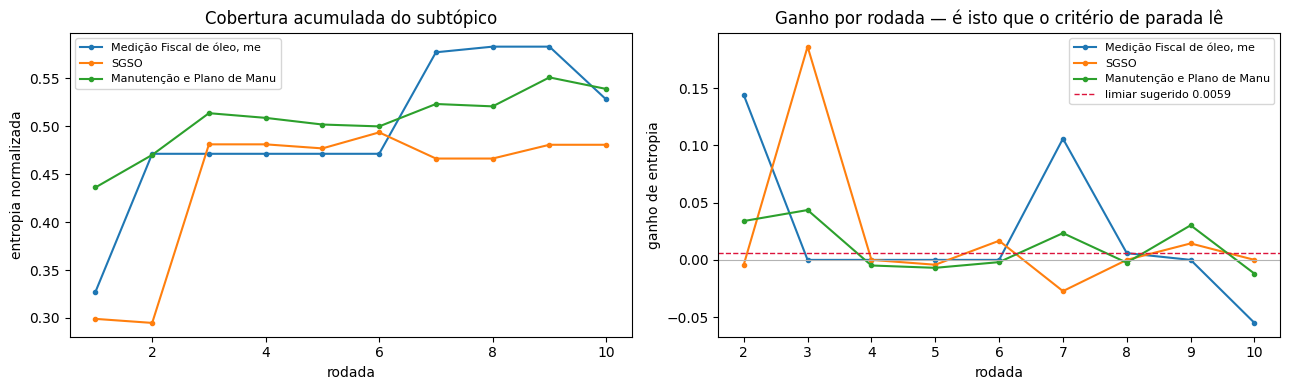

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for s, h in historicos.items():
    if h:
        ax1.plot(range(1, len(h) + 1), h, marker="o", ms=3, label=s[:26])
        ax2.plot(range(2, len(h) + 1), np.diff(h), marker="o", ms=3, label=s[:26])
ax1.set(xlabel="rodada", ylabel="entropia normalizada",
        title="Cobertura acumulada do subtópico")
ax2.axhline(limiar, color="crimson", ls="--", lw=1,
            label=f"limiar sugerido {limiar:.4f}")
ax2.axhline(0, color="0.7", lw=0.8)
ax2.set(xlabel="rodada", ylabel="ganho de entropia",
        title="Ganho por rodada — é isto que o critério de parada lê")
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 15. Resultado

In [ ]:
df = repo.dataframe()
print(f"{len(df)} questões no repositório\n")

if len(df):
    print(df.groupby("subtopico").agg(
        questoes=("id", "count"), nota_media=("nota", "mean"),
        refinadas=("refinada", "sum")).round(3).to_string())
    print()
    print("dificuldade:", dict(df.dificuldade.value_counts()))
    print("vícios (média):", df[[c for c in df if c.startswith("vicio_")]]
          .mean().round(3).to_dict())
    print(f"alto score (>= {cfg.nota_minima_fewshot}): "
          f"{(df.nota >= cfg.nota_minima_fewshot).sum()}")
df.sort_values("nota", ascending=False).head(10)

102 questões no repositório

                                                                                                      questoes  nota_media  refinadas
subtopico                                                                                                                            
Manutenção e Plano de Manutenção                                                                            40       0.910         36
Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações de offloading        28       0.868         23
SGSO                                                                                                        34       0.907         33

dificuldade: {'media': np.int64(97), 'facil': np.int64(4), 'dificil': np.int64(1)}
vícios (média): {'vicio_similaridade': 0.171, 'vicio_comprimento': 0.214, 'vicio_distratores': 0.059}
alto score (>= 0.8): 102


,id,topico,subtopico,faceta,rodada,nota,dificuldade,refinada,vicio_similaridade,vicio_comprimento,vicio_distratores,stem
73,ffde36b030-f0-d0-r3-q3,"Manutenção, Inspeção e Integridade de Ativos",Manutenção e Plano de Manutenção,filosofia e estrategia de manutencao e analise de criticidade,3,0.95,media,True,0.412,0.296,0.000,"Durante um teste de rotina, um SCE não atinge o PS estabelecido. A área operacional su..."
9,80d9d9002a-f0-d0-r2-q5,Produção e Processo (Medição Fiscal e Sistema de Alívio),"Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações...",projeto e instalacao de sistema de medicao fiscal,2,0.94,media,True,0.314,0.169,0.000,A equipe de integridade precisa definir um programa de inspeção da linha de transferên...
43,2f51e62cdd-f0-d0-r5-q0,"Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos",SGSO,governanca e cultura de seguranca,5,0.94,media,True,0.000,0.192,0.000,"Na preparação da matriz de correlação a ser enviada à ANP, o gestor deve mostrar como ..."
45,2f51e62cdd-f0-d0-r5-q4,"Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos",SGSO,governanca e cultura de seguranca,5,0.94,media,True,0.532,0.476,0.000,"Uma FPSO opera com múltiplas contratadas, com práticas de segurança heterogêneas. O ge..."
39,2f51e62cdd-f0-d0-r3-q2,"Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos",SGSO,governanca e cultura de seguranca,3,0.94,media,True,0.000,0.064,0.000,"Em auditoria interna, constatou-se que não conformidades críticas circulam por e-mail ..."
94,ffde36b030-f0-d0-r9-q1,"Manutenção, Inspeção e Integridade de Ativos",Manutenção e Plano de Manutenção,filosofia e estrategia de manutencao e analise de criticidade,9,0.94,media,True,0.432,0.493,0.000,"Em um FMECA recente, foram identificados três modos: (1) falha da válvula de alívio do..."
53,2f51e62cdd-f0-d0-r7-q0,"Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos",SGSO,governanca e cultura de seguranca,7,0.94,media,True,0.128,0.065,0.000,"Durante a mobilização de um FPSO, a diretoria busca demonstrar adesão ao SGSO aproveit..."
77,ffde36b030-f0-d0-r5-q0,"Manutenção, Inspeção e Integridade de Ativos",Manutenção e Plano de Manutenção,filosofia e estrategia de manutencao e analise de criticidade,5,0.94,media,True,0.143,0.486,0.333,Um trem de compressão de gás em um FPSO vem registrando trips por vibração em serviço ...
84,ffde36b030-f0-d0-r6-q1,"Manutenção, Inspeção e Integridade de Ativos",Manutenção e Plano de Manutenção,filosofia e estrategia de manutencao e analise de criticidade,6,0.94,media,True,0.006,0.241,0.333,"Ao elaborar o plano de manutenção de um FPSO, a equipe precisa definir a estratégia pa..."
48,2f51e62cdd-f0-d0-r6-q1,"Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos",SGSO,governanca e cultura de seguranca,6,0.93,facil,True,0.141,0.077,0.000,"Durante a revisão orçamentária de um FPSO, a alta gestão enfrenta restrições de caixa,..."


In [ ]:
# Posição do gabarito — deve estar uniforme; concentração aqui significa que o
# embaralhamento do §11 não rodou (`cfg.embaralhar_alternativas`).
if len(repo):
    print("posição da correta:",
          dict(Counter(chr(65 + q["correct_answer_index"]) for q in repo.questoes)))

posição da correta: {'D': 25, 'B': 33, 'A': 20, 'C': 24}


In [ ]:
# Export final.
destino = cfg.out_dir / "questoes_fase3.jsonl"
with open(destino, "w", encoding="utf-8") as fh:
    for q in repo.questoes:
        fh.write(json.dumps(q, ensure_ascii=False) + "\n")
print(f"{len(repo)} questões -> {destino}")
print(f"embeddings         -> {repo.caminho_emb}")
print(f"estado por subtópico -> {cfg.out_dir / 'estado'}")
print(f"log de rodadas       -> {cfg.out_dir / 'logs' / 'rodadas.jsonl'}")
print(f"\nuso de tokens:")
for nome, llm in [("leve", llm_leve), ("gerador", llm_gerador), ("judge", llm_judge)]:
    u = llm.usage
    print(f"  {nome:<8} {u.calls:>4} chamadas ({u.cached_calls} de cache) · "
          f"{u.prompt_tokens:>9,} in · {u.completion_tokens:>8,} out")

102 questões -> /home/gbs2/MCQ_CONTEXT_GEN/pipeline/fase_3/saida_fase3/questoes_fase3.jsonl
embeddings         -> /home/gbs2/MCQ_CONTEXT_GEN/pipeline/fase_3/saida_fase3/repositorio/embeddings.npy
estado por subtópico -> /home/gbs2/MCQ_CONTEXT_GEN/pipeline/fase_3/saida_fase3/estado
log de rodadas       -> /home/gbs2/MCQ_CONTEXT_GEN/pipeline/fase_3/saida_fase3/logs/rodadas.jsonl

uso de tokens:
  leve        8 chamadas (0 de cache) ·    11,371 in ·    8,645 out
  gerador   154 chamadas (0 de cache) ·   334,458 in ·  456,778 out
  judge      32 chamadas (0 de cache) ·    70,541 in ·   53,096 out


## 16. Da calibração para a execução completa

Com o limiar calibrado, expandir é trocar duas linhas:

```python
SUBTOPICOS_PILOTO = [(t, s) for t, subs in TOPICOS.items() for s in subs]
cfg.limiar_ganho_entropia = limiar
```

e reexecutar de §3 em diante. O que muda de custo:

- **§3 facetas** — uma chamada leve por subtópico novo, com cache;
- **§4 varredura** — a assinatura muda com o conjunto de facetas, então há uma
  nova passada no corpus (~8 min com os três arquivos, ~1 min sem o NILC). É o
  único custo grande que reaparece; rode uma vez, já com todos os subtópicos, se
  pretende expandir logo;
- **§5 em diante** — proporcional ao número de subtópicos.

O que revisar antes de soltar nos 40:

1. os documentos consolidados que começam com `AVISO:` — recuperação fraca
   naquela faceta, e questão gerada dali não presta;
2. a taxa de descarte do judge por subtópico — descarte alto costuma ser
   documento ruim, não gerador ruim;
3. as tolerâncias de vício contra a calibração do §9.1;
4. a distribuição de dificuldade — se o judge estiver marcando quase tudo como
   "media", a escala não está discriminando.